# CM3070 Final Project: Classifying Computing Publications by Discipline, Field and Research Methodology

**Template:** CM3060 Natural Language Processing, Project Idea "Identifying research methodologies that are used in research in the computing disciplines"

This notebook contains the full implementation of the project. It is organised in the same order as the pipeline in the report:

1. Setup and configuration
2. Data collection from the arXiv API
3. Dataset validation
4. Methodology annotation
5. Label hierarchy (discipline, field, methodology)
6. Text preprocessing
7. Feature extraction (TF-IDF and n-grams)
8. Rule-based keyword baseline
9. Machine learning models (Naive Bayes, Decision Tree, Logistic Regression)
10. Held-out test evaluation and confusion matrices
11. Feature and preprocessing experiments
12. Explainable classification output
13. Classifying a full PDF paper
14. Error analysis
15. Unit and integration tests
16. Saving outputs

The dataset and the manual annotations are saved as CSV files, so the notebook can be rerun without calling the arXiv API again (set `USE_CACHED_DATA = False` to rebuild the raw dataset).

## 1. Setup and configuration

In [1]:
import os
import re
import time
import json
import xml.etree.ElementTree as ET

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import requests

import nltk
from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer

from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.pipeline import Pipeline
from sklearn.naive_bayes import MultinomialNB
from sklearn.tree import DecisionTreeClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import StratifiedKFold, cross_validate, train_test_split
from sklearn.metrics import (accuracy_score, precision_recall_fscore_support,
                             classification_report, confusion_matrix,
                             ConfusionMatrixDisplay)
import joblib

pd.set_option("display.max_colwidth", 80)
RANDOM_STATE = 42
USE_CACHED_DATA = True

RAW_CSV = "raw_arxiv_primary_category.csv"
ANNOTATED_CSV = "arxiv_methodology_annotation.csv"
FIG_DIR = "figures"
os.makedirs(FIG_DIR, exist_ok=True)

In [2]:
# NLTK resources used for stop words and lemmatisation
for resource in ["stopwords", "wordnet", "omw-1.4"]:
    nltk.download(resource, quiet=True)

print("scikit-learn and NLTK ready")

scikit-learn and NLTK ready


## 2. Data collection from the arXiv API

Six arXiv computer science categories are used as the source of the *field* label. Only papers whose **primary** category matches the requested category are kept, because arXiv papers are often cross-listed and a cross-listed paper would give a noisy field label.

**Fix from the preliminary version.** The earlier notebook used `urllib.request` and failed with `HTTP Error 406: Not Acceptable` after the first request. Testing showed that the same query succeeded with `curl` and with the `requests` library but kept failing with `urllib`, even after long waits, so the problem was the client and not only the request rate. The function below therefore uses `requests`, asks for 150 results in a single call per category (six calls in total instead of eighteen), and keeps a retry with exponential backoff for genuine 429 or 5xx responses.

To make the dataset reproducible, the query is restricted to papers submitted on or before 31 August 2026 (window 1 June to 31 August 2026) and sorted by submission date, newest first. Because arXiv receives many papers per day in these categories, the 50 most recent primary-category papers per field all fall between 27 and 31 August 2026. The saved CSV is the fixed version of the dataset used in the report.

In [3]:
categories = {
    "cs.CL": "Natural Language Processing",
    "cs.AI": "Artificial Intelligence",
    "cs.LG": "Machine Learning",
    "cs.CR": "Cybersecurity",
    "cs.SE": "Software Engineering",
    "cs.HC": "Human-Computer Interaction"
}

ARXIV_API = "https://export.arxiv.org/api/query"
DATE_WINDOW = "[202606010000 TO 202608312359]"
PAPERS_PER_FIELD = 50

namespaces = {
    "atom": "http://www.w3.org/2005/Atom",
    "arxiv": "http://arxiv.org/schemas/atom"
}

In [4]:
def get_arxiv_papers(category, max_results=150, start=0):
    query = {
        "search_query": f"cat:{category} AND submittedDate:{DATE_WINDOW}",
        "start": start,
        "max_results": max_results,
        "sortBy": "submittedDate",
        "sortOrder": "descending"
    }
    headers = {"User-Agent": "CM3070-NLP-Project/1.0"}

    delay = 8
    for attempt in range(1, 6):
        response = requests.get(ARXIV_API, params=query, headers=headers, timeout=60)
        if response.status_code == 200:
            return response.content
        print(f"HTTP {response.status_code}; retrying in {delay}s (attempt {attempt}/5)")
        time.sleep(delay)
        delay *= 2

    raise RuntimeError(f"Could not fetch {category} from arXiv")


def clean_metadata(text):
    # arXiv titles and abstracts contain line breaks and double spaces
    return " ".join(text.split())


def parse_entries(xml_bytes, category, field_name, limit):
    root = ET.fromstring(xml_bytes)
    rows = []
    for entry in root.findall("atom:entry", namespaces):
        primary = entry.find("arxiv:primary_category", namespaces).attrib["term"]
        if primary != category:
            continue
        url = entry.find("atom:id", namespaces).text
        rows.append({
            "paper_id": url.split("/")[-1],
            "title": clean_metadata(entry.find("atom:title", namespaces).text),
            "abstract": clean_metadata(entry.find("atom:summary", namespaces).text),
            "published": entry.find("atom:published", namespaces).text[:10],
            "field": field_name,
            "arxiv_category": primary,
            "source": "arXiv",
            "source_url": url
        })
        if len(rows) == limit:
            break
    return rows

In [5]:
if USE_CACHED_DATA and os.path.exists(RAW_CSV):
    raw_df = pd.read_csv(RAW_CSV)
    print("Loaded cached raw dataset:", raw_df.shape)
else:
    collected = []
    for category, field_name in categories.items():
        xml_bytes = get_arxiv_papers(category)
        rows = parse_entries(xml_bytes, category, field_name, PAPERS_PER_FIELD)
        print(f"{field_name}: {len(rows)} papers kept")
        collected.extend(rows)
        time.sleep(6)  # stay polite to the arXiv API
    raw_df = pd.DataFrame(collected)
    raw_df.to_csv(RAW_CSV, index=False)
    print("Saved", RAW_CSV, raw_df.shape)

Loaded cached raw dataset: (300, 8)


## 3. Dataset validation

In [6]:
print("Total papers:", len(raw_df))
print("Duplicate paper IDs:", raw_df.duplicated(subset="paper_id").sum())
print("Missing abstracts:", raw_df["abstract"].isna().sum())
print("Published between", raw_df["published"].min(), "and", raw_df["published"].max())
raw_df["field"].value_counts()

Total papers: 300
Duplicate paper IDs: 0
Missing abstracts: 0
Published between 2026-08-27 and 2026-08-31


field
Natural Language Processing    50
Artificial Intelligence        50
Machine Learning               50
Cybersecurity                  50
Software Engineering           50
Human-Computer Interaction     50
Name: count, dtype: int64

In [7]:
# every paper should carry the arXiv category that matches its field label
mismatch = raw_df[raw_df["arxiv_category"].map(categories) != raw_df["field"]]
print("Field/category mismatches:", len(mismatch))

raw_df["abstract_words"] = raw_df["abstract"].str.split().str.len()
raw_df.groupby("field")["abstract_words"].describe()[["mean", "min", "max"]].round(1)

Field/category mismatches: 0


,mean,min,max
field,,,
Artificial Intelligence,192.9,120.0,289.0
Cybersecurity,199.1,59.0,286.0
Human-Computer Interaction,184.3,69.0,269.0
Machine Learning,182.0,54.0,270.0
Natural Language Processing,182.5,96.0,301.0
Software Engineering,199.6,96.0,317.0


## 4. Methodology annotation

### Annotation guide (final version)

Each publication is given one primary methodology label, based on its title and abstract.

* **Experimental**: tests or evaluates a model, algorithm, system or technique through controlled experiments, benchmarks or datasets.
* **Survey**: collects research data mainly through questionnaires or surveys of people. (A "survey paper" that summarises literature is a Review, not a Survey.)
* **Case Study**: examines one specific organisation, project, deployment or real-world setting in depth.
* **Qualitative**: uses interviews, observation, design probes or thematic analysis.
* **Design Science**: builds an artefact (tool, system, framework, protocol, architecture) to address a stated problem and demonstrates or evaluates it. The artefact itself is the main contribution.
* **Review**: reviews and synthesises existing research (systematic review, tutorial, perspective, roadmap, taxonomy).
* **Theoretical**: contributes proofs, formal analysis, analytical models or conceptual theory rather than an empirical evaluation.

**Change from the pilot guide.** The pilot guide had six labels. While annotating the Machine Learning and Cybersecurity papers, several abstracts only contained proofs, bounds or complexity results (for example regret bounds or an impossibility result for pseudorandom codes). Forcing them into *Experimental* would have made that label meaningless, so a seventh label, **Theoretical**, was added and the earlier papers were checked again.

**Decision rule between Experimental and Design Science.** If the main contribution is a model or algorithm benchmarked on datasets, the paper is Experimental. If the main contribution is a usable artefact built for a group of users or practitioners (a tool, platform or system), it is Design Science, even when it also reports measurements.

The helper functions below were used to read each paper and record the label and a short note. The completed annotations are stored in `arxiv_methodology_annotation.csv`.

In [8]:
methodology_labels = ["Experimental", "Survey", "Case Study", "Qualitative",
                      "Design Science", "Review", "Theoretical"]

annotation_df = pd.read_csv(ANNOTATED_CSV, keep_default_na=False)


def inspect_paper(index):
    paper = annotation_df.iloc[index]
    print("INDEX:", index, "| PAPER ID:", paper["paper_id"], "| FIELD:", paper["field"])
    print("\nTITLE:\n" + paper["title"])
    print("\nABSTRACT:\n" + paper["abstract"])
    print("\nLABEL:", paper["methodology"], "|", paper["annotation_notes"])


def annotate_paper(index, methodology, note):
    if methodology not in methodology_labels:
        print("Invalid methodology label. Use one of:", methodology_labels)
        return
    annotation_df.loc[index, "methodology"] = methodology
    annotation_df.loc[index, "annotation_notes"] = note


inspect_paper(203)

INDEX: 203 | PAPER ID: 2609.00247v1 | FIELD: Software Engineering

TITLE:
Empirical Software Engineering in Practice: Insights from Google

ABSTRACT:
While it is fairly well known how empirical software engineering (ESE) is used in the academic world, we have limited knowledge of how ESE is practiced in industry. As part of our regular column on empirical software engineering (ACM SIGSOFT SEN-ESE), we want to dedicate a series of articles to interviewing ESE practitioners from various companies. Among other things, we want to understand how ESE processes are implemented in industry, e.g., different research methods, how practitioners decide on what to study, how research results are used within companies and beyond, and if they face recurrent impediments to using ESE methods in industrial contexts. In the first edition of "ESE in Practice", we are joined by Ciera Jaspan and Collin Green from the Developer Intelligence team at Google. This article is a faithful account of our conversati

In [9]:
# sanity checks on the finished annotation file
assert len(annotation_df) == len(raw_df)
assert annotation_df["methodology"].isin(methodology_labels).all()
assert (annotation_df["annotation_notes"].str.len() > 0).all()
print("Unannotated papers:", (annotation_df["methodology"] == "").sum())

annotation_df["methodology"].value_counts()

Unannotated papers: 0


methodology
Experimental      193
Design Science     58
Theoretical        19
Case Study         13
Review              9
Qualitative         6
Survey              2
Name: count, dtype: int64

methodology,Experimental,Survey,Case Study,Qualitative,Design Science,Review,Theoretical
field,,,,,,,
Artificial Intelligence,35,0,3,0,8,3,1
Cybersecurity,31,0,0,0,11,3,5
Human-Computer Interaction,17,1,1,5,21,2,3
Machine Learning,39,0,0,0,2,1,8
Natural Language Processing,44,0,1,0,5,0,0
Software Engineering,27,1,8,1,11,0,2


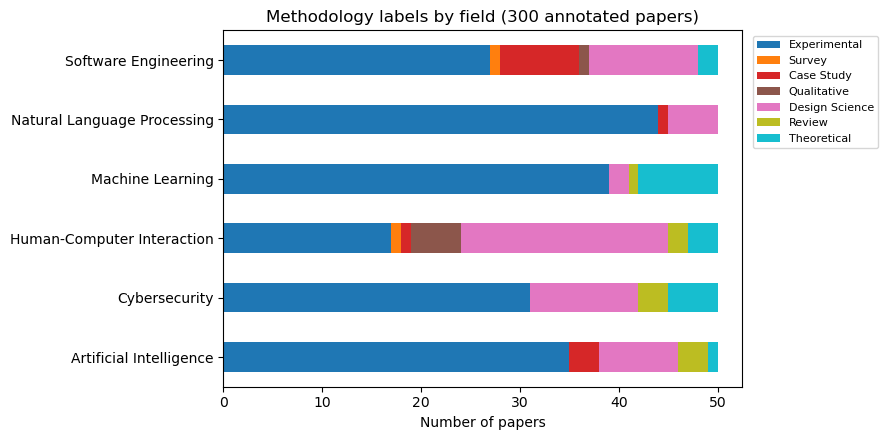

In [10]:
counts = pd.crosstab(annotation_df["field"], annotation_df["methodology"])
counts = counts[[m for m in methodology_labels if m in counts.columns]]
display(counts)

ax = counts.plot(kind="barh", stacked=True, figsize=(9, 4.5), colormap="tab10")
ax.set_xlabel("Number of papers")
ax.set_ylabel("")
ax.set_title("Methodology labels by field (300 annotated papers)")
ax.legend(bbox_to_anchor=(1.01, 1), loc="upper left", fontsize=8)
plt.tight_layout()
plt.savefig(f"{FIG_DIR}/fig_label_distribution.png", dpi=200)
plt.show()

## 5. Label hierarchy

**Discipline.** All six arXiv categories belong to Computer Science, so a flat "Computer Science" discipline label would carry no information. The project therefore uses a coarser grouping of the fields into three computing disciplines, loosely following the top level groupings of the ACM Computing Classification System:

| Discipline | Fields |
|---|---|
| Intelligent Systems | Natural Language Processing, Artificial Intelligence, Machine Learning |
| Software and Security | Software Engineering, Cybersecurity |
| Human-Centred Computing | Human-Computer Interaction |

**Grouped methodology.** Survey (2 papers) and Qualitative (6 papers) are far too rare for a supervised model to learn. Besides the full seven class scheme, the models are also evaluated on a four class scheme that merges related labels:

| Grouped label | Original labels |
|---|---|
| Experimental | Experimental |
| Design Science | Design Science |
| Theory and Review | Theoretical, Review |
| Human and Field Studies | Case Study, Qualitative, Survey |

In [11]:
discipline_map = {
    "Natural Language Processing": "Intelligent Systems",
    "Artificial Intelligence": "Intelligent Systems",
    "Machine Learning": "Intelligent Systems",
    "Software Engineering": "Software and Security",
    "Cybersecurity": "Software and Security",
    "Human-Computer Interaction": "Human-Centred Computing"
}

group_map = {
    "Experimental": "Experimental",
    "Design Science": "Design Science",
    "Theoretical": "Theory and Review",
    "Review": "Theory and Review",
    "Case Study": "Human and Field Studies",
    "Qualitative": "Human and Field Studies",
    "Survey": "Human and Field Studies"
}

data = annotation_df.copy()
data["discipline"] = data["field"].map(discipline_map)
data["methodology_group"] = data["methodology"].map(group_map)
data["text"] = data["title"] + ". " + data["abstract"]

for col in ["discipline", "field", "methodology", "methodology_group"]:
    print(col, dict(data[col].value_counts()))

discipline {'Intelligent Systems': np.int64(150), 'Software and Security': np.int64(100), 'Human-Centred Computing': np.int64(50)}
field {'Natural Language Processing': np.int64(50), 'Artificial Intelligence': np.int64(50), 'Machine Learning': np.int64(50), 'Cybersecurity': np.int64(50), 'Software Engineering': np.int64(50), 'Human-Computer Interaction': np.int64(50)}
methodology {'Experimental': np.int64(193), 'Design Science': np.int64(58), 'Theoretical': np.int64(19), 'Case Study': np.int64(13), 'Review': np.int64(9), 'Qualitative': np.int64(6), 'Survey': np.int64(2)}
methodology_group {'Experimental': np.int64(193), 'Design Science': np.int64(58), 'Theory and Review': np.int64(28), 'Human and Field Studies': np.int64(21)}


## 6. Text preprocessing

Steps: lowercasing, removal of LaTeX commands, URLs, numbers and punctuation, tokenisation, stop word removal and lemmatisation.

A standard English stop word list removes words that matter here. For example "study", "case" and "survey" are not in NLTK's list, but "we", "our" and "through" are, and phrases such as "we prove" or "we interviewed" are strong methodology cues. The stop word list is therefore reduced by a small set of *keep words* that were found to carry methodology information during annotation.

In [12]:
lemmatizer = WordNetLemmatizer()

KEEP_WORDS = {"we", "our", "not", "no", "against", "between", "through", "during",
              "how", "why", "what", "which", "who"}
STOP_WORDS = set(stopwords.words("english")) - KEEP_WORDS


def preprocess(text):
    text = text.lower()
    text = re.sub(r"\\[a-z]+\{([^}]*)\}", r" \1 ", text)   # \textbf{x} -> x
    text = re.sub(r"\$[^$]*\$", " ", text)                    # inline maths
    text = re.sub(r"https?://\S+", " ", text)                  # URLs
    text = re.sub(r"[^a-z\s-]", " ", text)                     # digits, punctuation
    text = text.replace("-", " ")
    tokens = text.split()
    tokens = [t for t in tokens if t not in STOP_WORDS and len(t) > 1]
    tokens = [lemmatizer.lemmatize(t) for t in tokens]
    return " ".join(tokens)


example = data.loc[214, "text"]
print("ORIGINAL:\n", example[:400])
print("\nPREPROCESSED:\n", preprocess(example)[:400])

ORIGINAL:
 Developer Attitudes and Practices Towards Optimizing Software Energy Consumption. Context: Software significantly influences the efficiency with which hardware resources are utilized, yet software energy consumption is seldom treated as a first-class concern in day-to-day development practice. Objective: This study investigates professional developers' attitudes, decision-making, and development p

PREPROCESSED:
 developer attitude practice towards optimizing software energy consumption context software significantly influence efficiency which hardware resource utilized yet software energy consumption seldom treated first class concern day day development practice objective study investigates professional developer attitude decision making development practice related software energy consumption particular



PREPROCESSED:
 developer attitude practice towards optimizing software energy consumption context software significantly influence efficiency which hardware resource utilized yet software energy consumption seldom treated first class concern day day development practice objective study investigates professional developer attitude decision making development practice related software energy consumption particular


In [13]:
data["clean_text"] = data["text"].apply(preprocess)

# check that methodology cue words survive preprocessing
cue_words = ["survey", "experiment", "dataset", "interview", "case", "study",
             "evaluation", "prove", "review", "participant", "questionnaire"]
check = preprocess("We conducted a Survey, experiments on a dataset, interviews, a case study "
                   "and an evaluation; we prove bounds, review work, recruit participants "
                   "and use a questionnaire.")
print(check)
print("Missing cue words:", [w for w in cue_words if w not in check.split()])

data["clean_tokens"] = data["clean_text"].str.split().str.len()
print("Average tokens per paper after preprocessing:", round(data["clean_tokens"].mean(), 1))

we conducted survey experiment dataset interview case study evaluation we prove bound review work recruit participant use questionnaire
Missing cue words: []
Average tokens per paper after preprocessing: 149.9


## 7. Feature extraction

TF-IDF weights each term by how often it appears in a paper and down-weights terms that appear in most papers. Unigrams and bigrams are used so that phrases like "case study", "user study" and "systematic review" become features in their own right. The table below shows the n-grams with the highest average TF-IDF weight inside each methodology class, which is a first check that the features carry methodology information.

In [14]:
tfidf = TfidfVectorizer(ngram_range=(1, 2), min_df=2, sublinear_tf=True)
X_all = tfidf.fit_transform(data["clean_text"])
terms = np.array(tfidf.get_feature_names_out())
print("Documents x features:", X_all.shape)

top_terms = {}
for label in methodology_labels:
    mask = (data["methodology"] == label).values
    mean_weights = np.asarray(X_all[mask].mean(axis=0)).ravel()
    top_terms[label] = ", ".join(terms[mean_weights.argsort()[::-1][:8]])
pd.DataFrame.from_dict(top_terms, orient="index", columns=["top TF-IDF n-grams"])

Documents x features: (300, 5357)


,top TF-IDF n-grams
Experimental,"model, we, llm, language, across, agent, task, language model"
Survey,"harm, disability, energy, vr, consumption, online survey, social, developer"
Case Study,"ai, agent, development, case study, study, legacy, one, we"
Qualitative,"guideline, discussion, how, visualization, affective, practitioner, research..."
Design Science,"system, agent, we, user, based, present, we present, tool"
Review,"cybersecurity, artificial, intelligence, ai, artificial intelligence, learni..."
Theoretical,"network, algorithm, we, learning, problem, our, how, game"


In [15]:
bigram_counts = {}
for label in ["Design Science", "Theoretical", "Human and Field Studies"]:
    col = "methodology_group" if label == "Human and Field Studies" else "methodology"
    docs = data.loc[data[col] == label, "clean_text"]
    bigram_vec = TfidfVectorizer(ngram_range=(2, 2), use_idf=False, norm=None)
    counts_matrix = bigram_vec.fit_transform(docs)
    totals = np.asarray(counts_matrix.sum(axis=0)).ravel()
    names = bigram_vec.get_feature_names_out()
    bigram_counts[label] = ", ".join(names[totals.argsort()[::-1][:8]])
pd.DataFrame.from_dict(bigram_counts, orient="index", columns=["most frequent bigrams"])

,most frequent bigrams
Design Science,"we present, language model, large language, we introduce, multi agent, we ev..."
Theoretical,"system theory, speaker anonymization, neural network, structure behavior, se..."
Human and Field Studies,"ai agent, coding agent, case study, energy consumption, self efficacy, desig..."


## 8. Rule-based keyword baseline

The baseline scores each label by counting weighted keyword and phrase matches in the preprocessed text and returns the label with the highest score. Methodology rules are checked with a priority order because some cues are much more specific than others: an abstract containing "systematic review" is almost certainly a Review even if it also says "we evaluate". If no methodology rule fires, the baseline falls back to *Experimental*, the most common label in computing research. The discipline is derived from the predicted field.

In [16]:
FIELD_KEYWORDS = {
    "Natural Language Processing": ["language", "text", "linguistic", "translation", "speech",
                                    "token", "corpus", "sentence", "word", "nlp", "llm"],
    "Artificial Intelligence": ["agent", "reasoning", "planning", "knowledge", "world model",
                                "multi agent", "decision", "autonomous", "tool"],
    "Machine Learning": ["learning", "neural network", "training", "gradient", "optimization",
                         "regret", "convergence", "representation", "loss", "reinforcement"],
    "Cybersecurity": ["attack", "security", "privacy", "adversary", "vulnerability",
                      "malware", "threat", "cryptographic", "authentication", "injection"],
    "Software Engineering": ["software", "code", "developer", "testing", "repository", "bug",
                             "program", "api", "maintenance", "github"],
    "Human-Computer Interaction": ["user", "participant", "interaction", "interface", "vr",
                                   "design", "people", "experience", "reality", "visualization"]
}

# (label, phrases, weight). Checked in this order when scores tie.
METHOD_RULES = [
    ("Review", ["systematic review", "literature review", "review", "tutorial",
                "roadmap", "taxonomy", "perspective"], 3),
    ("Survey", ["questionnaire", "online survey", "respondent", "surveyed"], 3),
    ("Qualitative", ["interview", "thematic analysis", "focus group", "semi structured",
                     "design probe"], 3),
    ("Case Study", ["case study", "industrial", "deployed production", "real world setting",
                    "experience report"], 3),
    ("Theoretical", ["prove", "theorem", "bound", "complexity", "formal", "analytical",
                     "conceptual"], 2),
    ("Design Science", ["tool", "system", "framework", "platform", "prototype",
                        "architecture", "toolkit", "we present"], 1),
    ("Experimental", ["experiment", "benchmark", "dataset", "evaluate", "outperform",
                      "accuracy", "baseline", "result show"], 1),
]


def count_phrase(text, phrase):
    return len(re.findall(r"\b" + re.escape(phrase) + r"\b", text))


def rule_field(clean_text):
    scores = {f: sum(count_phrase(clean_text, k) for k in kws) for f, kws in FIELD_KEYWORDS.items()}
    return max(scores, key=scores.get)


def rule_methodology(clean_text, return_scores=False):
    scores = {}
    for label, phrases, weight in METHOD_RULES:
        scores[label] = weight * sum(1 for p in phrases if count_phrase(clean_text, p) > 0)
    best = max(scores.values())
    if best == 0:
        prediction = "Experimental"
    else:
        # the first rule in priority order that reaches the best score wins
        prediction = next(label for label, _, _ in METHOD_RULES if scores[label] == best)
    return (prediction, scores) if return_scores else prediction


data["rule_field"] = data["clean_text"].apply(rule_field)
data["rule_discipline"] = data["rule_field"].map(discipline_map)
data["rule_methodology"] = data["clean_text"].apply(rule_methodology)
data["rule_methodology_group"] = data["rule_methodology"].map(group_map)

In [17]:
def summarise(y_true, y_pred):
    p, r, f, _ = precision_recall_fscore_support(y_true, y_pred, average="macro", zero_division=0)
    return {"accuracy": accuracy_score(y_true, y_pred), "macro_precision": p,
            "macro_recall": r, "macro_f1": f}

targets = ["discipline", "field", "methodology", "methodology_group"]
baseline_rows = []
for t in targets:
    row = summarise(data[t], data["rule_" + t])
    row["target"] = t
    baseline_rows.append(row)
baseline_results = pd.DataFrame(baseline_rows).set_index("target").round(3)
baseline_results

,accuracy,macro_precision,macro_recall,macro_f1
target,,,,
discipline,0.723,0.767,0.679,0.690
field,0.497,0.574,0.497,0.503
methodology,0.493,0.339,0.480,0.358
methodology_group,0.517,0.452,0.535,0.452


In [18]:
# how precise is each methodology rule when it fires, and how much of its class does it find?
rule_quality = []
for label, _, _ in METHOD_RULES:
    fired = data["rule_methodology"] == label
    true = data["methodology"] == label
    rule_quality.append({"rule": label, "times_fired": int(fired.sum()), "papers_with_label": int(true.sum()),
                         "precision": (true & fired).sum() / max(fired.sum(), 1),
                         "recall": (true & fired).sum() / max(true.sum(), 1)})
pd.DataFrame(rule_quality).set_index("rule").round(2)

,times_fired,papers_with_label,precision,recall
rule,,,,
Review,43,9,0.16,0.78
Survey,5,2,0.20,0.50
Qualitative,8,6,0.38,0.50
Case Study,12,13,0.17,0.15
Theoretical,24,19,0.25,0.32
Design Science,99,58,0.37,0.64
Experimental,109,193,0.84,0.48


## 9. Machine learning models

Three classifiers from the project design are compared: Multinomial Naive Bayes, a Decision Tree and Logistic Regression. Each one is wrapped in a scikit-learn `Pipeline` with the TF-IDF vectoriser, so that the vocabulary and IDF weights are learned only from the training folds. Fitting TF-IDF on all 300 papers before splitting would leak information from the test folds.

Evaluation uses stratified 5-fold cross-validation, repeated for each of the four targets. Macro-averaged F1 is the main metric because the methodology labels are heavily imbalanced, and accuracy alone would reward a model that always predicts *Experimental*. Decision Tree and Logistic Regression use `class_weight="balanced"` so that rare classes are not ignored during training.

Note: for the seven class methodology target, Survey has only two papers, so some folds contain no Survey paper. scikit-learn warns about this and the per-class scores for Survey should not be trusted. This is one of the reasons the grouped scheme is reported.

In [19]:
import warnings
warnings.filterwarnings("ignore", category=UserWarning)


def make_models(ngram_range=(1, 2)):
    def vec():
        return TfidfVectorizer(ngram_range=ngram_range, min_df=2, sublinear_tf=True)
    return {
        "Naive Bayes": Pipeline([("tfidf", vec()), ("clf", MultinomialNB(alpha=0.1))]),
        "Decision Tree": Pipeline([("tfidf", vec()), ("clf", DecisionTreeClassifier(
            max_depth=20, class_weight="balanced", random_state=RANDOM_STATE))]),
        "Logistic Regression": Pipeline([("tfidf", vec()), ("clf", LogisticRegression(
            C=10, max_iter=2000, class_weight="balanced"))]),
    }


cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)
scoring = {"accuracy": "accuracy", "macro_precision": "precision_macro",
           "macro_recall": "recall_macro", "macro_f1": "f1_macro"}


def run_cv(text_column="clean_text", ngram_range=(1, 2), target_list=targets):
    rows = []
    for t in target_list:
        for name, model in make_models(ngram_range).items():
            scores = cross_validate(model, data[text_column], data[t], cv=cv, scoring=scoring)
            rows.append({"target": t, "model": name,
                         **{k: scores["test_" + k].mean() for k in scoring},
                         "macro_f1_std": scores["test_macro_f1"].std()})
    return pd.DataFrame(rows)


cv_results = run_cv()
for t in targets:
    b = baseline_results.loc[t]
    cv_results = pd.concat([cv_results, pd.DataFrame([{"target": t, "model": "Rule-based baseline",
                                                      **b.to_dict(), "macro_f1_std": np.nan}])])
cv_results = cv_results.round(3).sort_values(["target", "macro_f1"], ascending=[True, False])
cv_results

,target,model,accuracy,macro_precision,macro_recall,macro_f1,macro_f1_std
2,discipline,Logistic Regression,0.800,0.825,0.758,0.772,0.086
0,discipline,Naive Bayes,0.797,0.827,0.737,0.751,0.108
0,discipline,Rule-based baseline,0.723,0.767,0.679,0.690,NaN
1,discipline,Decision Tree,0.580,0.534,0.528,0.524,0.033
5,field,Logistic Regression,0.620,0.630,0.620,0.617,0.045
3,field,Naive Bayes,0.603,0.621,0.603,0.601,0.057
0,field,Rule-based baseline,0.497,0.574,0.497,0.503,NaN
4,field,Decision Tree,0.407,0.409,0.407,0.397,0.097
0,methodology,Rule-based baseline,0.493,0.339,0.480,0.358,NaN
7,methodology,Decision Tree,0.527,0.247,0.249,0.239,0.039


target,discipline,field,methodology,methodology_group
model,,,,
Rule-based baseline,0.690,0.503,0.358,0.452
Naive Bayes,0.751,0.601,0.143,0.225
Decision Tree,0.524,0.397,0.239,0.308
Logistic Regression,0.772,0.617,0.216,0.392


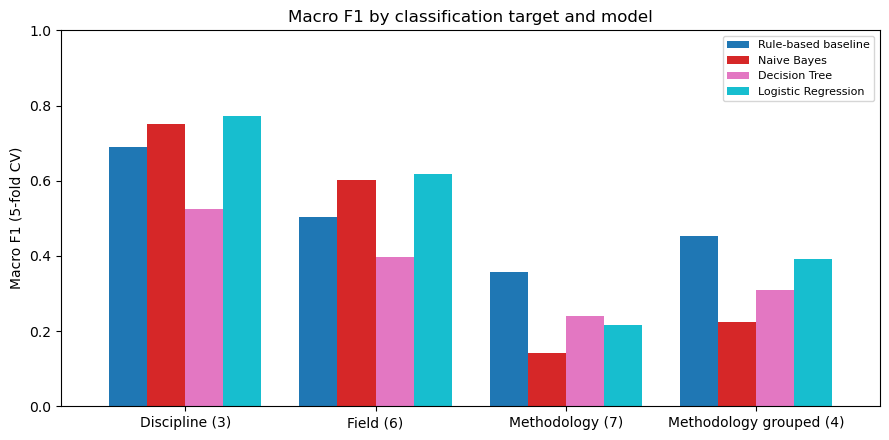

In [20]:
pivot = cv_results.pivot(index="model", columns="target", values="macro_f1")[targets]
pivot = pivot.loc[["Rule-based baseline", "Naive Bayes", "Decision Tree", "Logistic Regression"]]
display(pivot)

ax = pivot.T.plot(kind="bar", figsize=(9, 4.5), width=0.8, colormap="tab10")
ax.set_ylabel("Macro F1 (5-fold CV)")
ax.set_xlabel("")
ax.set_ylim(0, 1)
ax.set_xticklabels(["Discipline (3)", "Field (6)", "Methodology (7)", "Methodology grouped (4)"], rotation=0)
ax.set_title("Macro F1 by classification target and model")
ax.legend(fontsize=8, loc="upper right")
plt.tight_layout()
plt.savefig(f"{FIG_DIR}/fig_model_comparison.png", dpi=200)
plt.show()

In [21]:
# majority class reference: what accuracy and macro F1 does "always predict the most common label" get?
majority_rows = []
for t in targets:
    most_common = data[t].value_counts().idxmax()
    majority_rows.append({"target": t, "majority_label": most_common,
                          **summarise(data[t], [most_common] * len(data))})
pd.DataFrame(majority_rows).set_index("target").round(3)

,majority_label,accuracy,macro_precision,macro_recall,macro_f1
target,,,,,
discipline,Intelligent Systems,0.500,0.167,0.333,0.222
field,Natural Language Processing,0.167,0.028,0.167,0.048
methodology,Experimental,0.643,0.092,0.143,0.112
methodology_group,Experimental,0.643,0.161,0.250,0.196


## 10. Held-out test evaluation

Cross-validation gives the most reliable average. To look at individual errors, the data is also split once into 80% training and 20% test (stratified by field so every field is represented), and Logistic Regression is trained on the training part only.

In [22]:
train_df, test_df = train_test_split(data, test_size=0.2, stratify=data["field"],
                                     random_state=RANDOM_STATE)
print("Train:", len(train_df), "Test:", len(test_df))

final_models = {}
for t in ["field", "methodology_group", "methodology"]:
    model = make_models()["Logistic Regression"]
    model.fit(train_df["clean_text"], train_df[t])
    final_models[t] = model
    pred = model.predict(test_df["clean_text"])
    print("=" * 70)
    print("TARGET:", t)
    print(classification_report(test_df[t], pred, zero_division=0))

disc_pred = pd.Series(final_models["field"].predict(test_df["clean_text"])).map(discipline_map)
print("Discipline accuracy (derived from predicted field):",
      round(accuracy_score(test_df["discipline"], disc_pred), 3))

Train: 240 Test: 60
TARGET: field
                             precision    recall  f1-score   support

    Artificial Intelligence       0.62      0.50      0.56        10
              Cybersecurity       1.00      1.00      1.00        10
 Human-Computer Interaction       0.86      0.60      0.71        10
           Machine Learning       0.57      0.80      0.67        10
Natural Language Processing       0.55      0.60      0.57        10
       Software Engineering       0.80      0.80      0.80        10

                   accuracy                           0.72        60
                  macro avg       0.73      0.72      0.72        60
               weighted avg       0.73      0.72      0.72        60

TARGET: methodology_group
                         precision    recall  f1-score   support

         Design Science       0.60      0.27      0.38        11
           Experimental       0.77      0.98      0.86        41
Human and Field Studies       1.00      0.20      0

TARGET: field
                             precision    recall  f1-score   support

    Artificial Intelligence       0.62      0.50      0.56        10
              Cybersecurity       1.00      1.00      1.00        10
 Human-Computer Interaction       0.86      0.60      0.71        10
           Machine Learning       0.57      0.80      0.67        10
Natural Language Processing       0.55      0.60      0.57        10
       Software Engineering       0.80      0.80      0.80        10

                   accuracy                           0.72        60
                  macro avg       0.73      0.72      0.72        60
               weighted avg       0.73      0.72      0.72        60



TARGET: methodology_group
                         precision    recall  f1-score   support

         Design Science       0.60      0.27      0.38        11
           Experimental       0.77      0.98      0.86        41
Human and Field Studies       1.00      0.20      0.33         5
      Theory and Review       1.00      0.67      0.80         3

               accuracy                           0.77        60
              macro avg       0.84      0.53      0.59        60
           weighted avg       0.77      0.77      0.72        60



TARGET: methodology
                precision    recall  f1-score   support

    Case Study       0.00      0.00      0.00         4
Design Science       0.57      0.36      0.44        11
  Experimental       0.77      0.98      0.86        41
        Review       0.00      0.00      0.00         0
        Survey       0.00      0.00      0.00         1
   Theoretical       0.00      0.00      0.00         3

      accuracy                           0.73        60
     macro avg       0.22      0.22      0.22        60
  weighted avg       0.63      0.73      0.67        60

Discipline accuracy (derived from predicted field): 0.883


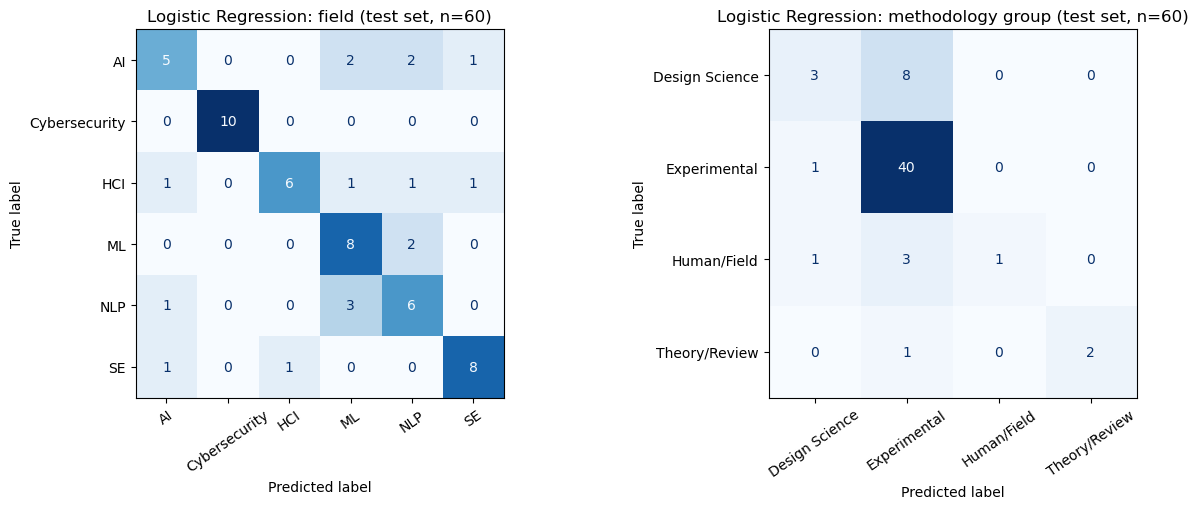

In [23]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5.2))
for ax, t in zip(axes, ["field", "methodology_group"]):
    labels = sorted(data[t].unique())
    pred = final_models[t].predict(test_df["clean_text"])
    cm = confusion_matrix(test_df[t], pred, labels=labels)
    short = [l.replace("Natural Language Processing", "NLP").replace("Human-Computer Interaction", "HCI")
              .replace("Artificial Intelligence", "AI").replace("Machine Learning", "ML")
              .replace("Software Engineering", "SE").replace("Human and Field Studies", "Human/Field")
              .replace("Theory and Review", "Theory/Review") for l in labels]
    ConfusionMatrixDisplay(cm, display_labels=short).plot(ax=ax, cmap="Blues", colorbar=False)
    ax.set_title(f"Logistic Regression: {t.replace('_', ' ')} (test set, n={len(test_df)})")
    ax.tick_params(axis="x", rotation=35)
plt.tight_layout()
plt.savefig(f"{FIG_DIR}/fig_confusion_matrices.png", dpi=200)
plt.show()

## 10b. Hybrid classifier (rules + Logistic Regression)

The cross-validation results show that the keyword baseline has a higher macro F1 for methodology than any of the trained models, while Logistic Regression has the higher accuracy. The two approaches fail in different places: the model is good at the common Experimental class, and the rules are good at spotting rare but explicit cues such as "systematic review", "interview", "questionnaire", "case study" or "we prove".

The hybrid classifier uses the Logistic Regression prediction by default, but lets the rule-based prediction override it when a *specific* rule fires (Review, Survey, Qualitative, Case Study or Theoretical). The rule for Design Science is never allowed to override because words like "system" and "framework" appear in almost every computing abstract.

A first version allowed every specific rule to override. It raised recall on the rare classes but also produced many false Review and Theoretical labels, because single words such as "perspective", "bound" or "analytical" also appear in ordinary experimental papers. The final version therefore learns *which* rules to trust from the training data: inside each training fold it measures the precision of every specific rule, and only rules with a training precision of at least 0.5 may override the model. The threshold was fixed before looking at test folds, and nothing is tuned on the test folds. Both versions are reported below.

In [24]:
SPECIFIC_RULES = {"Review", "Survey", "Qualitative", "Case Study", "Theoretical"}
MIN_RULE_PRECISION = 0.5


def trusted_rules(train_part, target, min_precision=MIN_RULE_PRECISION):
    # specific rules whose precision on the training data reaches the threshold
    fine = target == "methodology"
    trusted = set()
    for r in SPECIFIC_RULES:
        fired = train_part[train_part["rule_methodology"] == r]
        if len(fired) == 0:
            continue
        expected = r if fine else group_map[r]
        if (fired[target] == expected).mean() >= min_precision:
            trusted.add(r)
    return trusted


def hybrid_cv(target, learn_trust=True):
    fine = target == "methodology"
    preds = pd.Series(index=data.index, dtype=object)
    trusted_log = []
    for train_idx, test_idx in cv.split(data, data[target]):
        train_part = data.iloc[train_idx]
        allowed = trusted_rules(train_part, target) if learn_trust else SPECIFIC_RULES
        trusted_log.append(sorted(allowed))
        model = make_models()["Logistic Regression"]
        model.fit(train_part["clean_text"], train_part[target])
        ml_pred = model.predict(data["clean_text"].iloc[test_idx])
        rule_pred = data["rule_methodology"].iloc[test_idx].values
        combined = [(r if fine else group_map[r]) if r in allowed else m
                    for m, r in zip(ml_pred, rule_pred)]
        preds.iloc[test_idx] = combined
    return preds, trusted_log


hybrid_rows = []
for t in ["methodology", "methodology_group"]:
    naive_pred, _ = hybrid_cv(t, learn_trust=False)
    hybrid_rows.append({"target": t, "model": "Hybrid v1 (all specific rules)", **summarise(data[t], naive_pred)})
    data["hybrid_" + t], log = hybrid_cv(t, learn_trust=True)
    hybrid_rows.append({"target": t, "model": "Hybrid v2 (trusted rules)", **summarise(data[t], data["hybrid_" + t])})
    print(t, "rules trusted in each fold:", log)

hybrid_results = pd.DataFrame(hybrid_rows)
comparison = pd.concat([cv_results[cv_results["target"].isin(["methodology", "methodology_group"])]
                        .drop(columns="macro_f1_std"), hybrid_results]).round(3)
comparison.to_csv("results_hybrid_comparison.csv", index=False)
comparison.sort_values(["target", "macro_f1"], ascending=[True, False])

methodology rules trusted in each fold: [['Qualitative'], [], [], ['Qualitative'], []]
methodology_group rules trusted in each fold: [['Qualitative'], ['Qualitative'], [], ['Qualitative'], []]


,target,model,accuracy,macro_precision,macro_recall,macro_f1
0,methodology,Rule-based baseline,0.493,0.339,0.480,0.358
0,methodology,Hybrid v1 (all specific rules),0.570,0.353,0.456,0.354
7,methodology,Decision Tree,0.527,0.247,0.249,0.239
8,methodology,Logistic Regression,0.683,0.246,0.221,0.216
1,methodology,Hybrid v2 (trusted rules),0.677,0.459,0.201,0.212
6,methodology,Naive Bayes,0.653,0.153,0.167,0.143
2,methodology_group,Hybrid v1 (all specific rules),0.597,0.500,0.509,0.454
0,methodology_group,Rule-based baseline,0.517,0.452,0.535,0.452
3,methodology_group,Hybrid v2 (trusted rules),0.687,0.523,0.376,0.401
11,methodology_group,Logistic Regression,0.693,0.531,0.379,0.392


,target,model,accuracy,macro_precision,macro_recall,macro_f1
0,methodology,Rule-based baseline,0.493,0.339,0.480,0.358
0,methodology,Hybrid v1 (all specific rules),0.570,0.353,0.456,0.354
7,methodology,Decision Tree,0.527,0.247,0.249,0.239
8,methodology,Logistic Regression,0.683,0.246,0.221,0.216
1,methodology,Hybrid v2 (trusted rules),0.677,0.459,0.201,0.212
6,methodology,Naive Bayes,0.653,0.153,0.167,0.143
2,methodology_group,Hybrid v1 (all specific rules),0.597,0.500,0.509,0.454
0,methodology_group,Rule-based baseline,0.517,0.452,0.535,0.452
3,methodology_group,Hybrid v2 (trusted rules),0.687,0.523,0.376,0.401
11,methodology_group,Logistic Regression,0.693,0.531,0.379,0.392


In [25]:
print(classification_report(data["methodology_group"], data["hybrid_methodology_group"], zero_division=0))
print(classification_report(data["methodology"], data["hybrid_methodology"], zero_division=0))

                         precision    recall  f1-score   support

         Design Science       0.48      0.24      0.32        58
           Experimental       0.72      0.95      0.82       193
Human and Field Studies       0.29      0.10      0.14        21
      Theory and Review       0.60      0.21      0.32        28

               accuracy                           0.69       300
              macro avg       0.52      0.38      0.40       300
           weighted avg       0.64      0.69      0.63       300

                precision    recall  f1-score   support

    Case Study       0.00      0.00      0.00        13
Design Science       0.50      0.29      0.37        58
  Experimental       0.71      0.95      0.81       193
   Qualitative       0.00      0.00      0.00         6
        Review       1.00      0.11      0.20         9
        Survey       0.00      0.00      0.00         2
   Theoretical       1.00      0.05      0.10        19

      accuracy             

## 11. Feature and preprocessing experiments

The PPR planned to test different n-gram ranges and to check whether preprocessing helps. Three small experiments are run with Logistic Regression and 5-fold CV:

1. n-gram range: unigrams, unigrams + bigrams, unigrams to trigrams
2. text input: title only versus title + abstract
3. preprocessing: raw text (lowercased only by the vectoriser) versus the full preprocessing pipeline

In [26]:
exp_targets = ["field", "methodology_group"]


def lr_cv(text_column, ngram_range):
    out = {}
    for t in exp_targets:
        model = make_models(ngram_range)["Logistic Regression"]
        s = cross_validate(model, data[text_column], data[t], cv=cv, scoring="f1_macro")
        out[t] = s["test_score"].mean()
    return out

data["clean_title"] = data["title"].apply(preprocess)

experiments = []
for ng in [(1, 1), (1, 2), (1, 3)]:
    experiments.append({"experiment": f"n-gram range {ng}", **lr_cv("clean_text", ng)})
experiments.append({"experiment": "title only", **lr_cv("clean_title", (1, 2))})
experiments.append({"experiment": "raw text (no preprocessing)", **lr_cv("text", (1, 2))})
experiment_results = pd.DataFrame(experiments).set_index("experiment").round(3)
experiment_results.columns = ["field macro F1", "methodology group macro F1"]
experiment_results

,field macro F1,methodology group macro F1
experiment,,
"n-gram range (1, 1)",0.602,0.396
"n-gram range (1, 2)",0.617,0.392
"n-gram range (1, 3)",0.615,0.394
title only,0.378,0.411
raw text (no preprocessing),0.622,0.336


## 12. Explainable classification output

The final system returns, for each paper, the predicted discipline, field and methodology together with the model's confidence and the terms in the paper that pushed the prediction most strongly. For Logistic Regression the contribution of a term to a class is its TF-IDF value multiplied by the class coefficient, so the explanation is exact for this model rather than an approximation.

For methodology, the system reports the grouped label (more reliable) and the fine-grained label. Both use the hybrid rule from section 10b: when a specific methodology cue is found, the matched phrase is shown first in the supporting terms and the confidence shown is still the model's own probability for its original choice, so a low confidence next to a rule-based label signals that the two sources disagreed.

In [27]:
def top_class_terms(model, n=10):
    vec, clf = model.named_steps["tfidf"], model.named_steps["clf"]
    names = vec.get_feature_names_out()
    rows = {}
    for i, label in enumerate(clf.classes_):
        rows[label] = ", ".join(names[np.argsort(clf.coef_[i])[::-1][:n]])
    return pd.DataFrame.from_dict(rows, orient="index", columns=["strongest positive terms"])

display(top_class_terms(final_models["methodology_group"]))
display(top_class_terms(final_models["field"], n=8))

,strongest positive terms
Design Science,"we present, check, present, system, user, overhead, task, tool, report, work..."
Experimental,"llm, model, language, token, language model, inference, trained, fine, inter..."
Human and Field Studies,"practice, sensemaking, guideline, engineering, built, student, interpretive,..."
Theory and Review,"learning, algorithm, dimension, network, property, progress, cybersecurity, ..."


,strongest positive terms
Artificial Intelligence,"action, reasoning, observation, progress, agent, model, bias, uncertainty"
Cybersecurity,"attack, security, channel, authentication, adversarial, detection, defense, key"
Human-Computer Interaction,"user, visualization, participant, visual, ai, study, physical, interactive"
Machine Learning,"learning, network, neural, neural network, quantization, optimization, predi..."
Natural Language Processing,"rubric, llm, clinical, entity, nlp, layer, english, language"
Software Engineering,"software, engineering, code, developer, verification, specification, applica..."


In [28]:
def explain(model, clean_text, n_terms=5):
    vec, clf = model.named_steps["tfidf"], model.named_steps["clf"]
    x = vec.transform([clean_text])
    proba = clf.predict_proba(x)[0]
    k = proba.argmax()
    contrib = x.toarray()[0] * clf.coef_[k]
    names = vec.get_feature_names_out()
    top = [names[i] for i in contrib.argsort()[::-1][:n_terms] if contrib[i] > 0]
    return clf.classes_[k], proba[k], top


FINAL_TRUSTED_RULES = trusted_rules(train_df, "methodology_group")
print("Rules trusted by the final classifier (learned on the training split):", sorted(FINAL_TRUSTED_RULES))


def classify_paper(title, abstract, paper_id="new paper"):
    clean = preprocess(title + ". " + abstract)
    field, f_conf, f_terms = explain(final_models["field"], clean)
    group, g_conf, g_terms = explain(final_models["methodology_group"], clean)
    fine, m_conf, _ = explain(final_models["methodology"], clean)
    rule_label = rule_methodology(clean)
    if rule_label in FINAL_TRUSTED_RULES:      # hybrid override, see section 10b
        group, fine = group_map[rule_label], rule_label
        g_terms = [p for lbl, phrases, _ in METHOD_RULES if lbl == rule_label
                   for p in phrases if count_phrase(clean, p) > 0] + g_terms
    return {
        "Publication ID": paper_id,
        "Predicted Discipline": discipline_map[field],
        "Predicted Field": field,
        "Field Confidence": round(f_conf, 2),
        "Predicted Methodology (grouped)": group,
        "Methodology Confidence": round(g_conf, 2),
        "Predicted Methodology (fine)": fine,
        "Supporting Terms": ", ".join(dict.fromkeys(g_terms + f_terms[:3]))
    }


sample = test_df.sample(8, random_state=1)
output_table = pd.DataFrame([classify_paper(r.title, r.abstract, r.paper_id)
                             for r in sample.itertuples()])
output_table["True Field"] = sample["field"].values
output_table["True Methodology"] = sample["methodology"].values
output_table

Rules trusted by the final classifier (learned on the training split): ['Qualitative']


,Publication ID,Predicted Discipline,Predicted Field,Field Confidence,Predicted Methodology (grouped),Methodology Confidence,Predicted Methodology (fine),Supporting Terms,True Field,True Methodology
0,2608.30910v1,Intelligent Systems,Natural Language Processing,0.31,Experimental,0.90,Experimental,"llm, model, guided, language model, specific, training, corpus",Machine Learning,Experimental
1,2609.00491v1,Intelligent Systems,Natural Language Processing,0.30,Experimental,0.74,Experimental,"llm, context, model, dataset, fine, training, improves",Natural Language Processing,Experimental
2,2609.00427v1,Intelligent Systems,Artificial Intelligence,0.28,Experimental,0.55,Experimental,"reasoning, retrieval, fine, generation, real world, agent",Artificial Intelligence,Design Science
3,2609.00043v1,Software and Security,Software Engineering,0.41,Theory and Review,0.39,Experimental,"theory, structure, definition, aspect, representation, perspective, behavior...",Software Engineering,Theoretical
4,2608.31007v1,Intelligent Systems,Natural Language Processing,0.40,Human and Field Studies,0.46,Qualitative,"interview, language, interaction, model, trained, strongest, clinical, patie...",Human-Computer Interaction,Experimental
5,2608.28001v1,Human-Centred Computing,Human-Computer Interaction,0.43,Human and Field Studies,0.51,Qualitative,"interview, focus group, preference, synthetic, generation, diversity, iterat...",Human-Computer Interaction,Design Science
6,2609.00309v1,Software and Security,Cybersecurity,0.30,Experimental,0.65,Experimental,"inference, strategy, additional, llm, non, adversarial, channel, attack",Cybersecurity,Experimental
7,2609.00196v1,Intelligent Systems,Machine Learning,0.38,Experimental,0.83,Experimental,"weight, model, simple, accuracy, fine, optimization",Machine Learning,Experimental


## 13. Classifying a full PDF paper

The design proposed using selected sections of a paper (title, abstract, introduction, methodology and conclusion) rather than the whole PDF, because the full text contains references, tables and figure captions. The models are trained on titles and abstracts, which are available for every arXiv paper, but the function below shows how a PDF can be passed through the same pipeline: the text is extracted with `pypdf`, section headings are located with simple regular expressions, and only the selected sections are classified.

A paper from the test set is downloaded from arXiv as an example. The downloaded file is cached locally.

In [29]:
from pypdf import PdfReader

SECTION_PATTERN = re.compile(
    r"\n\s*(?:\d+\.?\s*)?(abstract|introduction|related work|background|method(?:s|ology)?|"
    r"approach|experiments?|evaluation|results|discussion|conclusions?|references)\s*\n",
    flags=re.IGNORECASE)
WANTED = {"abstract", "introduction", "method", "methods", "methodology", "approach", "conclusion", "conclusions"}


def extract_sections(pdf_path, max_pages=12):
    reader = PdfReader(pdf_path)
    text = "\n".join((page.extract_text() or "") for page in reader.pages[:max_pages])
    matches = list(SECTION_PATTERN.finditer(text))
    sections = {}
    for i, m in enumerate(matches):
        name = m.group(1).lower()
        end = matches[i + 1].start() if i + 1 < len(matches) else len(text)
        if name in WANTED and name not in sections:
            sections[name] = text[m.end():end]
    title = text.strip().split("\n")[0]
    return title, sections, len(text)


def classify_pdf(pdf_path, paper_id):
    title, sections, n_chars = extract_sections(pdf_path)
    if not sections:
        raise ValueError("No known section headings found in PDF")
    selected = " ".join(sections.values())
    print(f"Extracted {n_chars} characters; using sections: {list(sections)} ({len(selected)} characters)")
    return classify_paper(title, selected, paper_id)


example_id = test_df.iloc[0]["paper_id"]
pdf_path = f"pdf_cache/{example_id}.pdf"
os.makedirs("pdf_cache", exist_ok=True)
if not os.path.exists(pdf_path):
    r = requests.get(f"https://arxiv.org/pdf/{example_id}", headers={"User-Agent": "CM3070-NLP-Project/1.0"}, timeout=60)
    r.raise_for_status()
    open(pdf_path, "wb").write(r.content)

pdf_result = classify_pdf(pdf_path, example_id)
abstract_result = classify_paper(test_df.iloc[0]["title"], test_df.iloc[0]["abstract"], example_id)
pd.DataFrame([abstract_result, pdf_result], index=["title + abstract", "PDF sections"]).T

Extracted 69890 characters; using sections: ['abstract', 'introduction', 'methodology', 'conclusion'] (37292 characters)


,title + abstract,PDF sections
Publication ID,2608.28844v1,2608.28844v1
Predicted Discipline,Human-Centred Computing,Human-Centred Computing
Predicted Field,Human-Computer Interaction,Human-Computer Interaction
Field Confidence,0.46,0.37
Predicted Methodology (grouped),Experimental,Experimental
Methodology Confidence,0.65,0.6
Predicted Methodology (fine),Experimental,Experimental
Supporting Terms,"deep, model, deep learning, balance, classification, participant, vr, user","balance, trained, model, balanced, classification, participant, user, vr"


## 14. Error analysis

Looking at the papers the model gets wrong helps to separate model errors from genuinely ambiguous cases. The table below lists misclassified test papers for the grouped methodology target, with the annotation note that explains the true label.

In [30]:
test_view = test_df.copy()
test_view["predicted"] = final_models["methodology_group"].predict(test_view["clean_text"])
errors = test_view[test_view["predicted"] != test_view["methodology_group"]]
print(f"{len(errors)} of {len(test_view)} test papers misclassified (grouped methodology)")
errors[["paper_id", "title", "field", "methodology", "predicted", "annotation_notes"]]

14 of 60 test papers misclassified (grouped methodology)


,paper_id,title,field,methodology,predicted,annotation_notes
57,2609.00427v1,SpecMind: Enabling Spectrum Intelligence via Multi-Agent Hybrid Retrieval-Au...,Artificial Intelligence,Design Science,Experimental,Multi-agent RAG system built for spectrum management users.
64,2609.00274v1,Autoresearch for Marketplace Catalogs: From Legacy Forms to AI-Native Matching,Artificial Intelligence,Case Study,Experimental,Autoresearch loop deployed in production at a single marketplace.
70,2609.00226v1,ConvDeck: Conversational Paper-to-Slide Generation via Stage-Specific User F...,Artificial Intelligence,Design Science,Experimental,Interactive slide generation system with stage-wise user feedback.
297,2608.27390v1,Beyond Harassment: Exploring the Harm Experienced by People with Disabilitie...,Human-Computer Interaction,Survey,Experimental,Survey of people with disabilities on perceived harm severity in social VR.
232,2608.28880v1,FlowCheck: Helping End-Users Specify and Verify Intent in Vibe-Coded Web Apps,Software Engineering,Design Science,Experimental,"Constraint language and tool for end users, with evaluation."
240,2608.28403v1,Recovering Software Architecture Intent from Historical Work Items using Gen...,Software Engineering,Case Study,Experimental,Mixed-methods industry case study on architecture recovery.
284,2608.28819v1,Visible but Not Yet Curatable: Characterizing the Curatability of Compact an...,Human-Computer Interaction,Design Science,Experimental,Framework conceptualising curatability of LLM artefacts.
177,2608.30171v1,Reducio: Optimized Confidential Serverless Cloud Deployments for Enterprise ...,Cybersecurity,Design Science,Experimental,Serverless platform design with evaluation.
158,2609.00267v1,"Delegation Without Trust: An Empirical Gap Analysis of Identity, Authorizati...",Cybersecurity,Experimental,Design Science,Empirical gap analysis of multi-agent frameworks.
238,2608.28498v1,A System-of-Systems Case Study for the Verification of Composed Digital Twins,Software Engineering,Case Study,Design Science,System-of-systems case study on digital twin verification.


In [31]:
# which true/predicted pairs are most common among the cross-validated errors?
from sklearn.model_selection import cross_val_predict
cv_pred = cross_val_predict(make_models()["Logistic Regression"], data["clean_text"],
                            data["methodology_group"], cv=cv)
error_pairs = (pd.DataFrame({"true": data["methodology_group"], "predicted": cv_pred})
               .query("true != predicted").value_counts().rename("count"))
error_pairs.to_frame()

,,count
true,predicted,
Design Science,Experimental,41
Theory and Review,Experimental,19
Human and Field Studies,Experimental,11
Experimental,Design Science,6
Human and Field Studies,Design Science,6
Theory and Review,Design Science,3
Design Science,Human and Field Studies,2
Human and Field Studies,Theory and Review,2
Experimental,Theory and Review,1


In [32]:
# does the model do better in some fields than others?
data["cv_pred_group"] = cv_pred
data.groupby("field").apply(
    lambda g: pd.Series({"papers": len(g),
                         "accuracy": accuracy_score(g["methodology_group"], g["cv_pred_group"]),
                         "non_experimental_share": (g["methodology_group"] != "Experimental").mean()})
).round(2)

C:\Users\Berwyn\AppData\Local\Temp\ipykernel_25844\43434403.py:3: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  data.groupby("field").apply(


,papers,accuracy,non_experimental_share
field,,,
Artificial Intelligence,50.0,0.76,0.30
Cybersecurity,50.0,0.64,0.38
Human-Computer Interaction,50.0,0.44,0.66
Machine Learning,50.0,0.78,0.22
Natural Language Processing,50.0,0.90,0.12
Software Engineering,50.0,0.64,0.46


## 15. Unit and integration tests

The tests below check each stage of the pipeline separately (unit tests) and the full path from raw text to output table (integration test). They use plain `assert` statements inside a `unittest` test case so that they run inside the notebook.

In [33]:
import unittest


class PipelineTests(unittest.TestCase):

    def test_clean_metadata_removes_extra_whitespace(self):
        self.assertEqual(clean_metadata("  A\n  title\twith   gaps "), "A title with gaps")

    def test_preprocess_lowercases_and_removes_punctuation(self):
        self.assertEqual(preprocess("Hello, World!"), "hello world")

    def test_preprocess_keeps_methodology_words(self):
        out = preprocess("We interviewed participants and ran a survey").split()
        for w in ["we", "interviewed", "participant", "survey"]:
            self.assertIn(w, out)

    def test_preprocess_removes_latex_and_numbers(self):
        out = preprocess("We report $x^2$ gains of 12.5% with \\textbf{BoldModel}")
        self.assertNotIn("12", out)
        self.assertIn("boldmodel", out)

    def test_preprocess_empty_string(self):
        self.assertEqual(preprocess(""), "")

    def test_rule_review(self):
        self.assertEqual(rule_methodology(preprocess("A systematic review of 65 papers")), "Review")

    def test_rule_survey(self):
        self.assertEqual(rule_methodology(preprocess("An online survey with 134 respondents")), "Survey")

    def test_rule_default_is_experimental(self):
        self.assertEqual(rule_methodology(preprocess("Something entirely unrelated")), "Experimental")

    def test_rule_field_security(self):
        self.assertEqual(rule_field(preprocess("A new attack on privacy and security")), "Cybersecurity")

    def test_discipline_map_covers_all_fields(self):
        self.assertEqual(set(discipline_map), set(categories.values()))

    def test_group_map_covers_all_labels(self):
        self.assertEqual(set(group_map), set(methodology_labels))

    def test_parse_entries_filters_cross_listed(self):
        xml = b'''<feed xmlns="http://www.w3.org/2005/Atom" xmlns:arxiv="http://arxiv.org/schemas/atom">
          <entry><id>http://arxiv.org/abs/1</id><title>A</title><summary>x</summary>
          <published>2026-06-01T00:00:00Z</published><arxiv:primary_category term="cs.CL"/></entry>
          <entry><id>http://arxiv.org/abs/2</id><title>B</title><summary>y</summary>
          <published>2026-06-01T00:00:00Z</published><arxiv:primary_category term="cs.LG"/></entry>
        </feed>'''
        rows = parse_entries(xml, "cs.CL", "Natural Language Processing", 10)
        self.assertEqual([r["paper_id"] for r in rows], ["1"])

    def test_classify_paper_output_structure(self):
        out = classify_paper("A user study of VR interfaces",
                             "We ran a study with 24 participants in virtual reality.")
        self.assertIn(out["Predicted Discipline"], set(discipline_map.values()))
        self.assertTrue(0 <= out["Field Confidence"] <= 1)
        self.assertIn(out["Predicted Methodology (grouped)"], set(group_map.values()))

    def test_integration_known_paper(self):
        # a clear HCI interview paper from the dataset should be classified as HCI
        row = data[data["title"].str.startswith("Delegating Before Learning")].iloc[0]
        out = classify_paper(row["title"], row["abstract"])
        self.assertEqual(out["Predicted Field"], "Human-Computer Interaction")


result = unittest.TextTestRunner(verbosity=2).run(
    unittest.defaultTestLoader.loadTestsFromTestCase(PipelineTests))
print("Tests run:", result.testsRun, "| failures:", len(result.failures), "| errors:", len(result.errors))

test_classify_paper_output_structure (__main__.PipelineTests.test_classify_paper_output_structure) ... ok
test_clean_metadata_removes_extra_whitespace (__main__.PipelineTests.test_clean_metadata_removes_extra_whitespace) ... ok
test_discipline_map_covers_all_fields (__main__.PipelineTests.test_discipline_map_covers_all_fields) ... ok
test_group_map_covers_all_labels (__main__.PipelineTests.test_group_map_covers_all_labels) ... ok
test_integration_known_paper (__main__.PipelineTests.test_integration_known_paper) ... ok
test_parse_entries_filters_cross_listed (__main__.PipelineTests.test_parse_entries_filters_cross_listed) ... ok
test_preprocess_empty_string (__main__.PipelineTests.test_preprocess_empty_string) ... ok
test_preprocess_keeps_methodology_words (__main__.PipelineTests.test_preprocess_keeps_methodology_words) ... ok
test_preprocess_lowercases_and_removes_punctuation (__main__.PipelineTests.test_preprocess_lowercases_and_removes_punctuation) ... ok
test_preprocess_removes_late

Tests run: 14 | failures: 0 | errors: 0


test_clean_metadata_removes_extra_whitespace (__main__.PipelineTests.test_clean_metadata_removes_extra_whitespace) ... 

ok


test_discipline_map_covers_all_fields (__main__.PipelineTests.test_discipline_map_covers_all_fields) ... 

...

ok


test_rule_survey (__main__.PipelineTests.test_rule_survey) ... 

ok


----------------------------------------------------------------------
Ran 14 tests in 0.049s

OK


Tests run: 14 | failures: 0 | errors: 0


## 16. Saving outputs

In [34]:
os.makedirs("models", exist_ok=True)
for t, model in final_models.items():
    joblib.dump(model, f"models/logreg_{t}.joblib")

cv_results.to_csv("results_cross_validation.csv", index=False)
experiment_results.to_csv("results_experiments.csv")
output_table.to_csv("results_sample_output.csv", index=False)
data.drop(columns=["clean_tokens"]).to_csv("dataset_with_predictions.csv", index=False)
print("Saved models, result tables and figures:", sorted(os.listdir(FIG_DIR)))

Saved models, result tables and figures: ['fig_confusion_matrices.png', 'fig_gantt.png', 'fig_label_distribution.png', 'fig_model_comparison.png', 'fig_pipeline.png']
